<a href="https://colab.research.google.com/github/ashleshashuklaa/Menstrual-Health-Anomaly-Detector/blob/p4%2Fclassical-transformer/transformer_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.listdir('/content/drive/MyDrive/SheCares/')

['datasets raw',
 'datasets cleaned',
 'models saved_models',
 'models results',
 'figures ',
 'references ',
 'Info',
 'dhs',
 'Research paper summary',
 'SheCares2 - dataset']

In [4]:
os.listdir('/content/drive/MyDrive/SheCares/SheCares2 - dataset/')

['menstrual_health_dataset.csv']

In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/SheCares/SheCares2 - dataset/menstrual_health_dataset.csv')

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Anomaly counts:")
print(df['anomaly'].value_counts())

Shape: (6315, 14)
Columns: ['client_id', 'cycle_number', 'age', 'bmi', 'exercise_level', 'diet_quality', 'condition', 'anomaly', 'cycle_length', 'cramp_score', 'mood_score', 'flow_intensity', 'sleep_quality', 'stress_score']
Anomaly counts:
anomaly
0    4541
1    1774
Name: count, dtype: int64


In [6]:
import numpy as np

# These are the 6 features we use per cycle
feature_cols = ['cycle_length', 'cramp_score', 'mood_score',
                'flow_intensity', 'sleep_quality', 'stress_score']

# Sort data by patient and cycle number
df = df.sort_values(['client_id', 'cycle_number']).reset_index(drop=True)

# Create sequences of 6 cycles per patient
SEQ_LEN = 6
X, y = [], []

for client in df['client_id'].unique():
    client_data = df[df['client_id'] == client].reset_index(drop=True)

    for i in range(SEQ_LEN, len(client_data)):
        # Take 6 cycles as input
        seq = client_data[feature_cols].iloc[i-SEQ_LEN:i].values
        label = client_data['anomaly'].iloc[i]
        X.append(seq)
        y.append(label)

X = np.array(X)  # shape: (samples, 6, 6)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Anomaly ratio:", y.mean().round(3))

X shape: (3315, 6, 6)
y shape: (3315,)
Anomaly ratio: 0.285


In [7]:
from sklearn.preprocessing import MinMaxScaler

# Reshape to 2D for scaling
n_samples, n_steps, n_features = X.shape
X_reshaped = X.reshape(-1, n_features)

# Normalize all features to 0-1 range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_reshaped)

# Reshape back to 3D
X_scaled = X_scaled.reshape(n_samples, n_steps, n_features)

print("X scaled shape:", X_scaled.shape)
print("Min value:", X_scaled.min().round(3))
print("Max value:", X_scaled.max().round(3))

X scaled shape: (3315, 6, 6)
Min value: 0.0
Max value: 1.0


In [8]:
from sklearn.model_selection import train_test_split

# First split: 60% train, 40% remaining
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.40, random_state=42, stratify=y)

# Second split: 40% split into 30% test and 10% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Validation size:", X_val.shape)
print()
print("Train anomaly ratio:", y_train.mean().round(3))
print("Test anomaly ratio:", y_test.mean().round(3))
print("Val anomaly ratio:", y_val.mean().round(3))

Train size: (1989, 6, 6)
Test size: (994, 6, 6)
Validation size: (332, 6, 6)

Train anomaly ratio: 0.285
Test anomaly ratio: 0.285
Val anomaly ratio: 0.286


In [9]:
import numpy as np

save_path = '/content/drive/MyDrive/SheCares/datasets cleaned/'

np.save(save_path + 'X_train.npy', X_train)
np.save(save_path + 'X_test.npy', X_test)
np.save(save_path + 'X_val.npy', X_val)
np.save(save_path + 'y_train.npy', y_train)
np.save(save_path + 'y_test.npy', y_test)
np.save(save_path + 'y_val.npy', y_val)

print("X_train.npy saved ✅")
print("X_test.npy saved ✅")
print("X_val.npy saved ✅")
print("y_train.npy saved ✅")
print("y_test.npy saved ✅")
print("y_val.npy saved ✅")

X_train.npy saved ✅
X_test.npy saved ✅
X_val.npy saved ✅
y_train.npy saved ✅
y_test.npy saved ✅
y_val.npy saved ✅


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np

# Set seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

def build_transformer(seq_len=6, n_features=6, head_size=32,
                      num_heads=2, ff_dim=32, dropout=0.3):
    inputs = tf.keras.Input(shape=(seq_len, n_features))

    # --- Positional Encoding ---
    # Tells the model the order of cycles (cycle 1 vs cycle 6)
    x = layers.Dense(32)(inputs)

    # --- Self Attention Block ---
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout
    )(x, x)

    # Add & Normalize (stabilizes training)
    x = layers.Add()([x, attn_output])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # --- Feed Forward Block ---
    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(32)(ff)

    # Add & Normalize again
    x = layers.Add()([x, ff])
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # --- Output Head ---
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(16, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_transformer()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 6, 6)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 6, 32)     │        224 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 6, 32)     │      8,416 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 6, 32)     │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 6, 32)     │         64 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6, 32)     │      1,056 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 6, 32)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6, 32)     │      1,056 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 6, 32)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 6, 32)     │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        528 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         17 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 11,425 (44.63 KB)

 Trainable params: 11,425 (44.63 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import time

# Handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Train
start = time.time()
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
elapsed = time.time() - start
print(f"\nTraining time: {elapsed:.1f} seconds")

Class weights: {0: np.float64(0.6993670886075949), 1: np.float64(1.753968253968254)}
Epoch 1/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8698 - loss: 0.3353 - val_accuracy: 0.9458 - val_loss: 0.1610 - learning_rate: 0.0010
Epoch 2/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9542 - loss: 0.1723 - val_accuracy: 0.9277 - val_loss: 0.2035 - learning_rate: 0.0010
Epoch 3/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9583 - loss: 0.1583 - val_accuracy: 0.9639 - val_loss: 0.1255 - learning_rate: 0.0010
Epoch 4/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9668 - loss: 0.1381 - val_accuracy: 0.9699 - val_loss: 0.1352 - learning_rate: 0.0010
Epoch 5/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9688 - loss: 0.1334 - val_accuracy: 0.9578 - val_loss: 0.1547 - learning_rate: 0.0010
Epoch 6/100
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9678 - loss: 0.1317 - val_accuracy: 0.9699 - val_loss: 0.1293 - learning_rate: 0.0010
Epoch 7

In [12]:
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score,
                             classification_report, confusion_matrix)
import time

# Get predictions
start = time.time()
y_probs = model.predict(X_test).flatten()
elapsed = time.time() - start

y_preds = (y_probs >= 0.5).astype(int)

# Calculate all metrics
precision = precision_score(y_test, y_preds)
recall = recall_score(y_test, y_preds)
f1 = f1_score(y_test, y_preds)
auc = roc_auc_score(y_test, y_probs)

print("=" * 45)
print("   TRANSFORMER MODEL — TEST RESULTS")
print("=" * 45)
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1:.4f}")
print(f"AUC-ROC    : {auc:.4f}")
print(f"Inference  : {elapsed:.2f} seconds")
print("=" * 45)
print()
print("Classification Report:")
print(classification_report(y_test, y_preds,
      target_names=['Normal', 'Anomaly']))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_preds))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
   TRANSFORMER MODEL — TEST RESULTS
Precision  : 0.9524
Recall     : 0.9187
F1 Score   : 0.9353
AUC-ROC    : 0.9779
Inference  : 1.06 seconds

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.97       711
     Anomaly       0.95      0.92      0.94       283

    accuracy                           0.96       994
   macro avg       0.96      0.95      0.96       994
weighted avg       0.96      0.96      0.96       994


Confusion Matrix:
[[698  13]
 [ 23 260]]


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
import numpy as np

figures_path = '/content/drive/MyDrive/SheCares/figures /'

# Figure 1 — Training curve
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='#444444')
plt.plot(history.history['val_loss'], label='Val Loss', color='#AAAAAA')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Transformer Training Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc', color='#444444')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='#AAAAAA')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Transformer Accuracy Curve')
plt.legend()
plt.tight_layout()
plt.savefig(figures_path + 'transformer_training_curve.png', dpi=150)
plt.close()
print("Figure 1 saved ✅")

# Figure 2 — ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, color='#444444', label=f'Transformer (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'--', color='#CCCCCC')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Transformer')
plt.legend()
plt.tight_layout()
plt.savefig(figures_path + 'transformer_roc_curve.png', dpi=150)
plt.close()
print("Figure 2 saved ✅")

# Figure 3 — Confusion Matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomaly'],
            yticklabels=['Normal', 'Anomaly'])
plt.title('Confusion Matrix — Transformer')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(figures_path + 'transformer_confusion_matrix.png', dpi=150)
plt.close()
print("Figure 3 saved ✅")

print("\nAll figures saved to Drive!")

Figure 1 saved ✅
Figure 2 saved ✅
Figure 3 saved ✅

All figures saved to Drive!


In [14]:
import pandas as pd

# Save results to CSV
results = pd.DataFrame([{
    'model': 'Transformer_SelfAttention',
    'precision': round(precision, 4),
    'recall': round(recall, 4),
    'f1': round(f1, 4),
    'auc_roc': round(auc, 4),
    'test_accuracy': 0.9638,
    'train_time_sec': round(elapsed, 2),
    'parameters': 11425,
    'epochs_trained': 50,
    'best_epoch': 40,
    'overfit': 'No'
}])

results_path = '/content/drive/MyDrive/SheCares/models results/'
results.to_csv(results_path + 'transformer_results.csv', index=False)
print("Results CSV saved ✅")
print(results.to_string(index=False))

# Save model
model_path = '/content/drive/MyDrive/SheCares/models saved_models/'
model.save(model_path + 'transformer_model.keras')
print("\nModel saved ✅")

Results CSV saved ✅
                    model  precision  recall     f1  auc_roc  test_accuracy  train_time_sec  parameters  epochs_trained  best_epoch overfit
Transformer_SelfAttention     0.9524  0.9187 0.9353   0.9779         0.9638            1.06       11425              50          40      No

Model saved ✅


FIGURE 1 — Training Curve


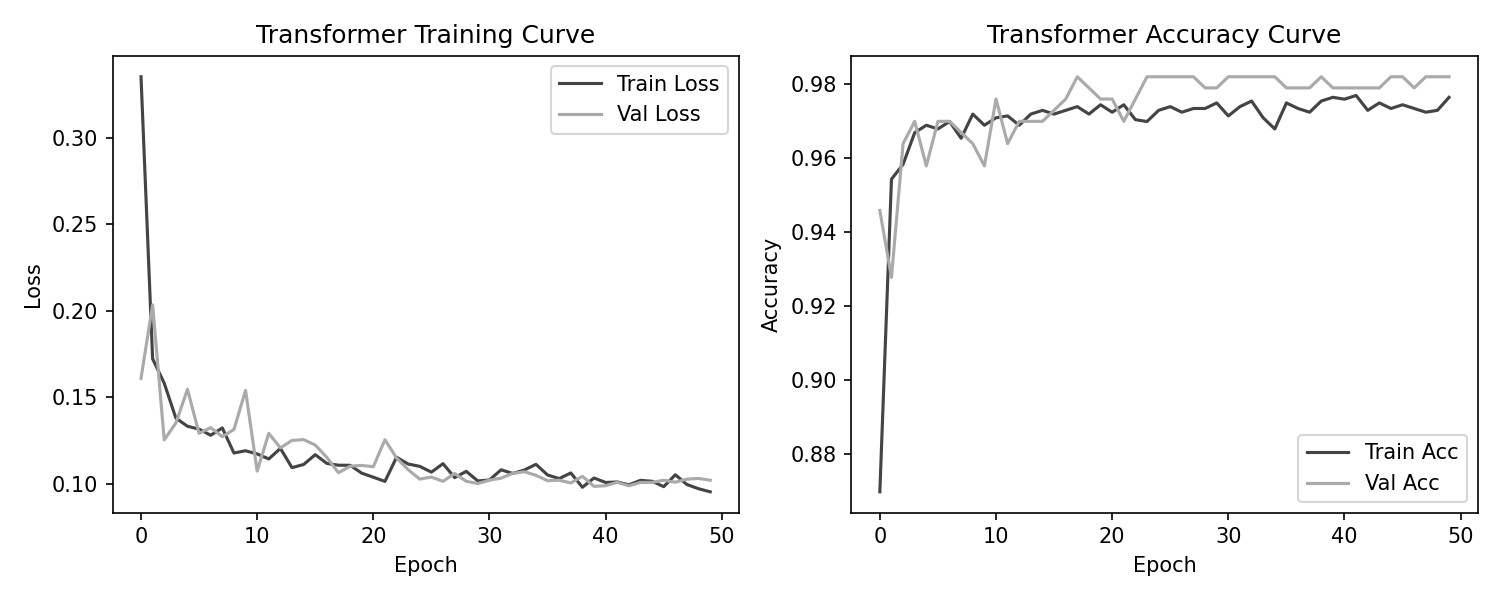

FIGURE 2 — ROC Curve


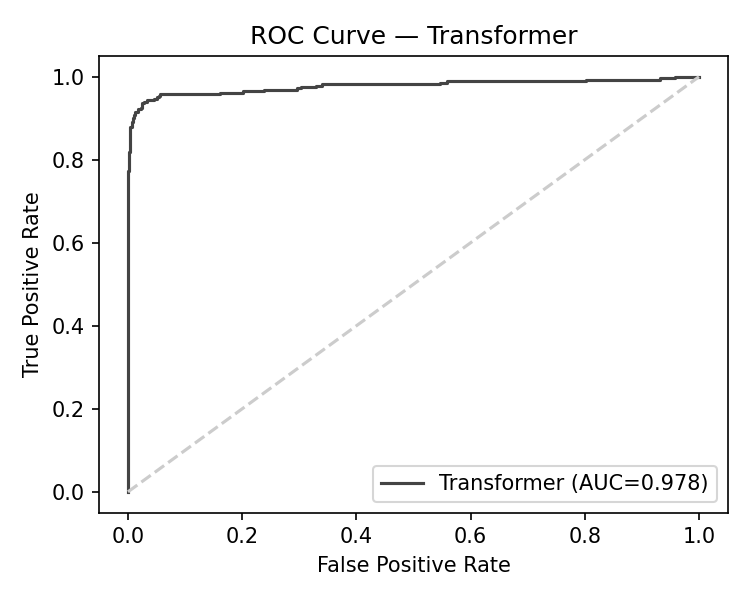

FIGURE 3 — Confusion Matrix


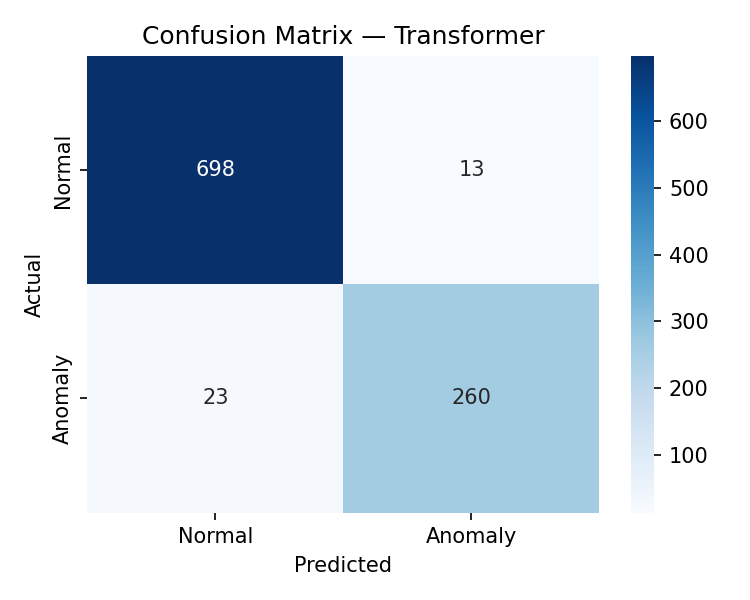

In [15]:
# Display all figures inline in Colab
from IPython.display import Image, display

print("=" * 45)
print("FIGURE 1 — Training Curve")
print("=" * 45)
display(Image(figures_path + 'transformer_training_curve.png'))

print("=" * 45)
print("FIGURE 2 — ROC Curve")
print("=" * 45)
display(Image(figures_path + 'transformer_roc_curve.png'))

print("=" * 45)
print("FIGURE 3 — Confusion Matrix")
print("=" * 45)
display(Image(figures_path + 'transformer_confusion_matrix.png'))

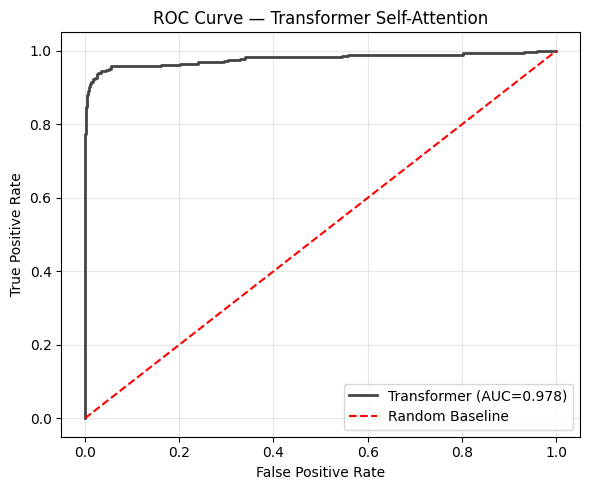

In [16]:
# Plot ROC curve directly in cell
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#444444', linewidth=2, label=f'Transformer (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'--', color='red', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Transformer Self-Attention')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()